# First project Machine Learning (Killian Le Milbeau)

Our goal here is to build and evaluate a model to "predict" customer churn on the 'celldata' dataset.
Then we want to analyze its fairness with respect to the sensitive attribute 'Gender'.

In [113]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline # For StratifiedKFold to avoid Data Leakage
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, RocCurveDisplay

rd_state = 42
np.random.seed(rd_state)

In [2]:
df = pd.read_csv("celldata.csv")

# 1 - Data exploration

## 1.1 - Introductive/General exploration

In [3]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Salary,Churn
0,632,Germany,Female,50,5,107959.39,1,1,1,6985,1
1,649,France,Female,42,7,0.00,2,0,1,22974,0
2,595,France,Male,29,6,150685.79,1,1,0,87771,0
3,653,Spain,Male,35,6,116662.96,2,1,1,23864,0
4,559,Spain,Female,40,7,144470.77,1,1,1,18918,0


In [4]:
df.shape

(8000, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CreditScore     8000 non-null   int64  
 1   Geography       8000 non-null   object 
 2   Gender          8000 non-null   object 
 3   Age             8000 non-null   int64  
 4   Tenure          8000 non-null   int64  
 5   Balance         8000 non-null   float64
 6   NumOfProducts   8000 non-null   int64  
 7   HasCrCard       8000 non-null   int64  
 8   IsActiveMember  8000 non-null   int64  
 9   Salary          8000 non-null   int64  
 10  Churn           8000 non-null   int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 687.6+ KB


In [6]:
df.isnull().sum()

CreditScore       0
Geography         0
Gender            0
Age               0
Tenure            0
Balance           0
NumOfProducts     0
HasCrCard         0
IsActiveMember    0
Salary            0
Churn             0
dtype: int64

In [7]:
df[df.duplicated()]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Salary,Churn


In [8]:
df.describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Salary,Churn
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,650.805000,38.871625,5.013000,76011.635494,1.533625,0.704750,0.515750,100211.396750,0.201125
std,96.721648,10.446006,2.897565,62402.105212,0.583448,0.456184,0.499783,57165.688096,0.400866
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,12.000000,0.000000
5%,488.950000,25.000000,1.000000,0.000000,1.000000,0.000000,0.000000,10032.450000,0.000000
25%,584.000000,32.000000,2.000000,0.000000,1.000000,0.000000,0.000000,51464.500000,0.000000
50%,652.000000,37.000000,5.000000,96846.565000,1.000000,1.000000,1.000000,100583.000000,0.000000
75%,718.000000,44.000000,7.000000,127593.625000,2.000000,1.000000,1.000000,149068.000000,0.000000
90%,778.000000,53.000000,9.000000,149083.920000,2.000000,1.000000,1.000000,179057.100000,1.000000
95%,812.000000,60.000000,10.000000,161899.416000,2.000000,1.000000,1.000000,189664.750000,1.000000


In [9]:
categorical_variables = [c for c in df.columns if (df[c].dtype == "object" or df[c].nunique() <= 11) and c != "Churn"]

categorical_variables

['Geography',
 'Gender',
 'Tenure',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember']

In [10]:
numeric_variables = [col for col in df.columns if df[col].dtype != "object"
                        and df[col].nunique() >11]
numeric_variables

['CreditScore', 'Age', 'Balance', 'Salary']

In [11]:
df["Churn"].value_counts()

Churn
0    6391
1    1609
Name: count, dtype: int64

In [12]:
churn = df.loc[df["Churn"]==1]
not_churn = df.loc[df["Churn"]==0]

## 1.2 - Categorical variables

In [13]:
# Frequency of not_churn group according to Tenure
not_churn["Tenure"].value_counts().sort_values()

Tenure
0     255
10    318
3     617
9     619
6     621
4     637
5     645
1     655
2     662
8     670
7     692
Name: count, dtype: int64

In [14]:
churn["Tenure"].value_counts().sort_values()

Tenure
0      77
10     83
7     138
8     142
6     157
5     157
4     161
9     163
2     169
3     175
1     187
Name: count, dtype: int64

In [15]:
# Frequency of not_churn group according to NumOfProducts
not_churn["NumOfProducts"].value_counts().sort_values()

NumOfProducts
3      38
1    2944
2    3409
Name: count, dtype: int64

In [16]:
churn["NumOfProducts"].value_counts().sort_values()

NumOfProducts
4      48
3     184
2     272
1    1105
Name: count, dtype: int64

In [17]:
# Examining the HasCrCard of the not_churn group
not_churn["HasCrCard"].value_counts()

HasCrCard
1    4512
0    1879
Name: count, dtype: int64

In [18]:
churn["HasCrCard"].value_counts()

HasCrCard
1    1126
0     483
Name: count, dtype: int64

In [19]:
# Examining the IsActiveMember of the not_churn group
not_churn["IsActiveMember"].value_counts()

IsActiveMember
1    3538
0    2853
Name: count, dtype: int64

In [20]:

churn["IsActiveMember"].value_counts()

IsActiveMember
0    1021
1     588
Name: count, dtype: int64

In [21]:
# Frequency of not_churn group according to Geography
not_churn.Geography.value_counts().sort_values()

Geography
Germany    1359
Spain      1658
France     3374
Name: count, dtype: int64

In [22]:
churn.Geography.value_counts().sort_values()

Geography
Spain      332
Germany    613
France     664
Name: count, dtype: int64

In [23]:
# Frequency of not_churn group according to Gender
not_churn.Gender.value_counts()

Gender
Male      3661
Female    2730
Name: count, dtype: int64

In [24]:
churn.Gender.value_counts()

Gender
Female    897
Male      712
Name: count, dtype: int64

## 1.3 - Numerical variables

In [25]:
not_churn["CreditScore"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count    6391.000000
mean      652.445314
std        95.488316
min       408.000000
5%        492.000000
25%       587.000000
50%       654.000000
75%       718.000000
90%       778.000000
95%       812.000000
99%       850.000000
max       850.000000
Name: CreditScore, dtype: float64

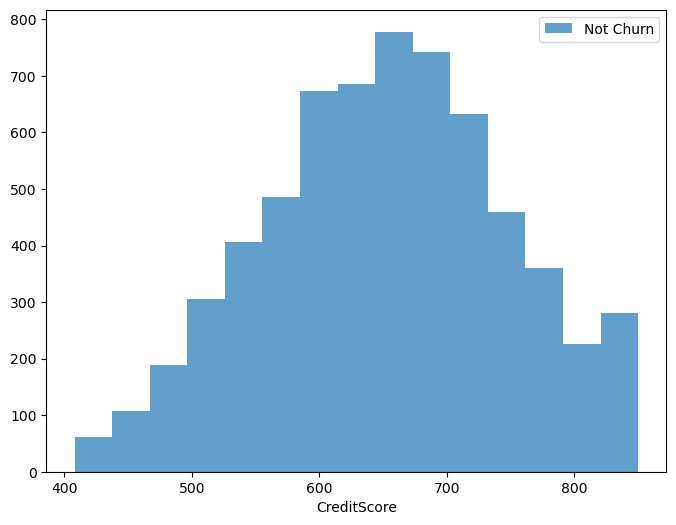

In [26]:
plt.figure(figsize=(8,6))
plt.xlabel('CreditScore')
plt.hist(not_churn["CreditScore"],bins=15, alpha=0.7, label='Not Churn')
plt.legend(loc='upper right')
plt.show()

In [27]:
churn["CreditScore"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count    1609.000000
mean      644.289621
std       101.241132
min       350.000000
5%        477.000000
25%       576.000000
50%       645.000000
75%       717.000000
90%       777.200000
95%       813.000000
99%       850.000000
max       850.000000
Name: CreditScore, dtype: float64

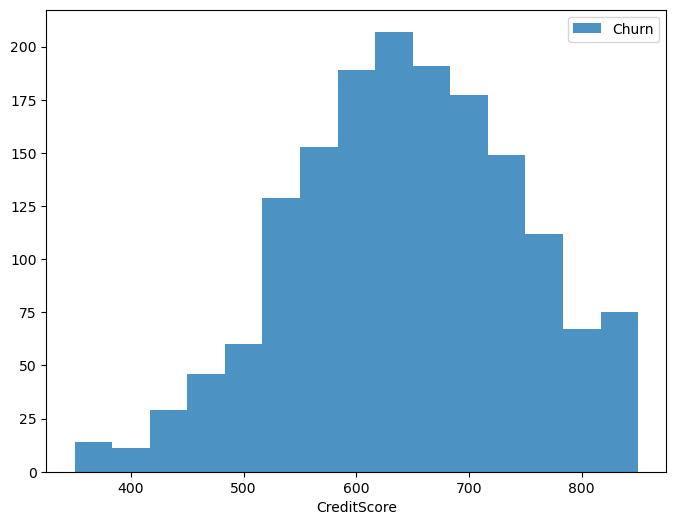

In [28]:
plt.figure(figsize=(8,6))
plt.xlabel('CreditScore')
plt.hist(churn["CreditScore"],bins=15, alpha=0.8, label='Churn')
plt.legend(loc='upper right')
plt.show()

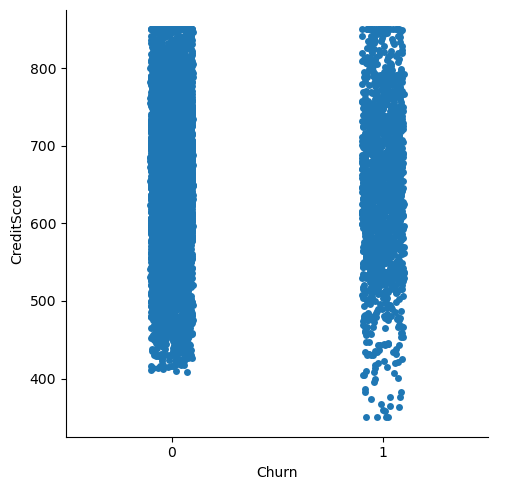

In [29]:
sns.catplot(x="Churn", y="CreditScore", data = df)

In [30]:
not_churn["Age"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count    6391.000000
mean       37.436238
std        10.116750
min        18.000000
5%         24.000000
25%        31.000000
50%        36.000000
75%        41.000000
90%        49.000000
95%        59.000000
99%        73.000000
max        92.000000
Name: Age, dtype: float64

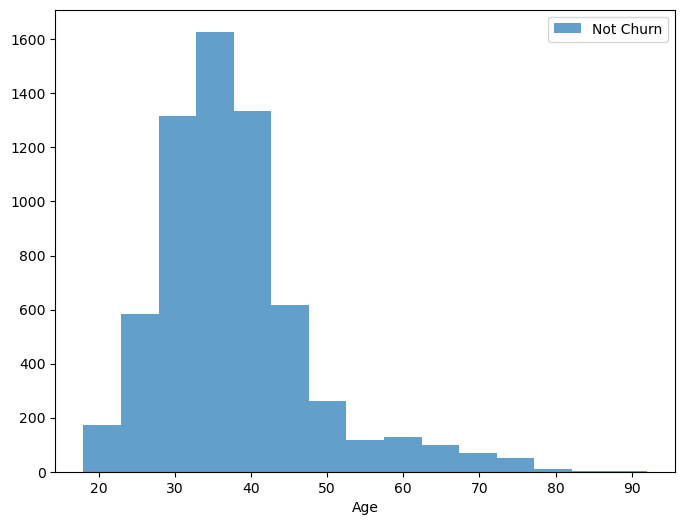

In [31]:
plt.figure(figsize=(8,6))
plt.xlabel('Age')
plt.hist(not_churn["Age"],bins=15, alpha=0.7, label='Not Churn')
plt.legend(loc='upper right')
plt.show()

In [32]:
churn["Age"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count    1609.000000
mean       44.573027
std         9.766097
min        18.000000
5%         28.400000
25%        38.000000
50%        45.000000
75%        51.000000
90%        57.000000
95%        61.000000
99%        68.000000
max        84.000000
Name: Age, dtype: float64

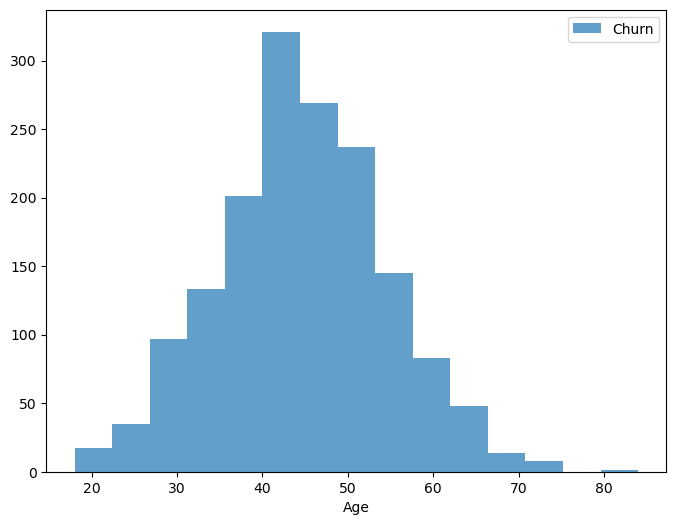

In [33]:
plt.figure(figsize=(8,6))
plt.xlabel('Age')
plt.hist(churn["Age"],bins=15, alpha=0.7, label='Churn')
plt.legend(loc='upper right')
plt.show()

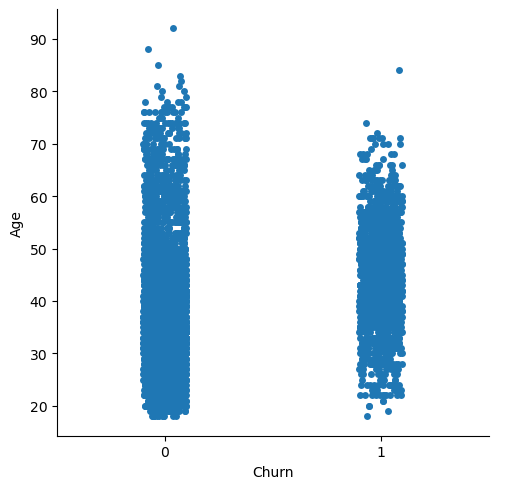

In [34]:
sns.catplot(x="Churn", y="Age", data = df)

In [35]:
not_churn["Balance"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count      6391.000000
mean      72330.303489
std       62754.607024
min           0.000000
5%            0.000000
25%           0.000000
50%       91621.690000
75%      126174.325000
90%      148556.740000
95%      160808.015000
99%      182792.374000
max      221532.800000
Name: Balance, dtype: float64

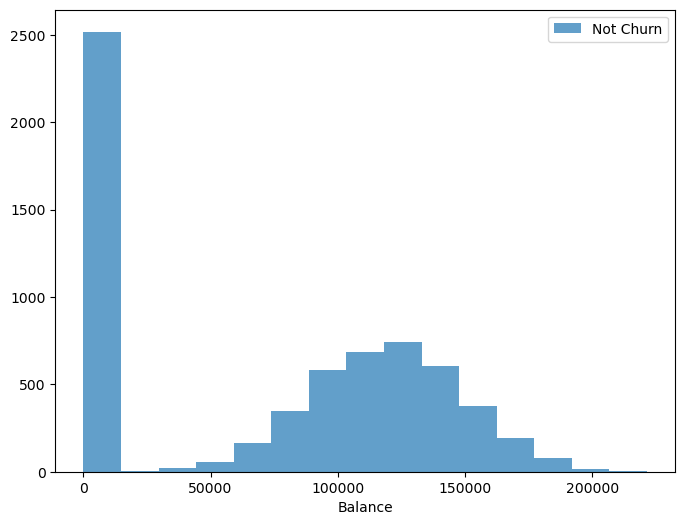

In [36]:
plt.figure(figsize=(8,6))
plt.xlabel('Balance')
plt.hist(not_churn["Balance"],bins=15, alpha=0.7, label='Not Churn')
plt.legend(loc='upper right')
plt.show()

In [37]:
churn["Balance"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count      1609.000000
mean      90634.005190
std       58764.912286
min           0.000000
5%            0.000000
25%           0.000000
50%      109172.880000
75%      131607.280000
90%      152078.774000
95%      168667.082000
99%      198281.475200
max      250898.090000
Name: Balance, dtype: float64

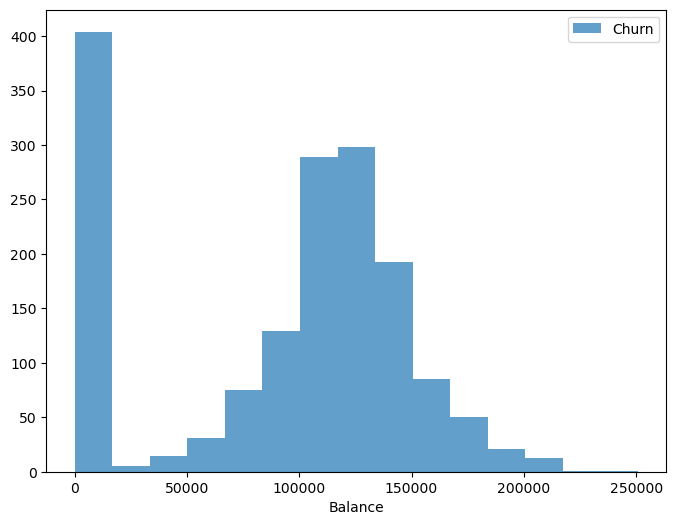

In [38]:
plt.figure(figsize=(8,6))
plt.xlabel('Balance')
plt.hist(churn["Balance"],bins=15, alpha=0.7, label='Churn')
plt.legend(loc='upper right')
plt.show()

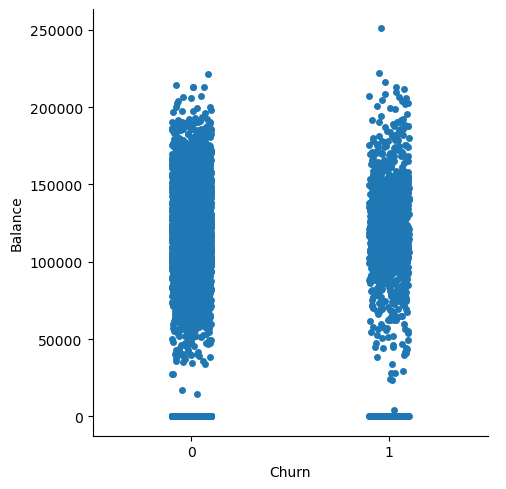

In [39]:
sns.catplot(x="Churn", y="Balance", data = df)

In [40]:
not_churn["Salary"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count      6391.000000
mean      99950.944923
std       57151.652811
min          90.000000
5%        10059.000000
25%       51115.000000
50%      100128.000000
75%      148708.500000
90%      179093.000000
95%      189729.500000
99%      198105.600000
max      199992.000000
Name: Salary, dtype: float64

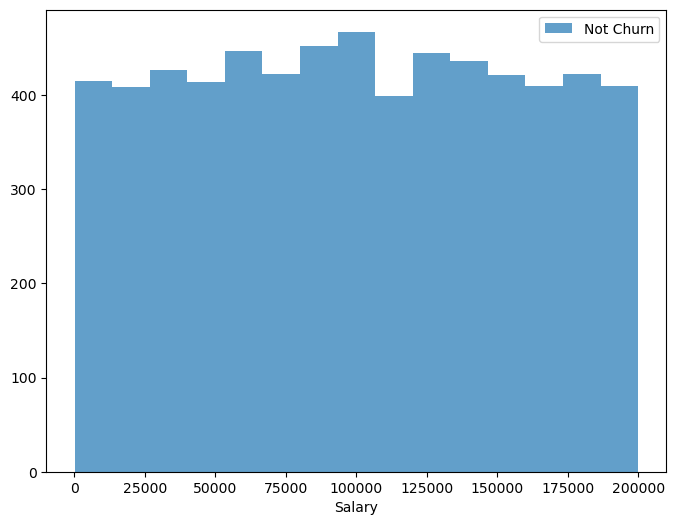

In [41]:
plt.figure(figsize=(8,6))
plt.xlabel('Salary')
plt.hist(not_churn["Salary"],bins=15, alpha=0.7, label='Not Churn')
plt.legend(loc='upper right')
plt.show()

In [42]:
churn["Salary"].describe([0.05,0.25,0.50,0.75,0.90,0.95,0.99])

count      1609.000000
mean     101245.919826
std       57227.472989
min          12.000000
5%         9841.800000
25%       52584.000000
50%      103379.000000
75%      149922.000000
90%      178729.400000
95%      188826.800000
99%      197450.880000
max      199808.000000
Name: Salary, dtype: float64

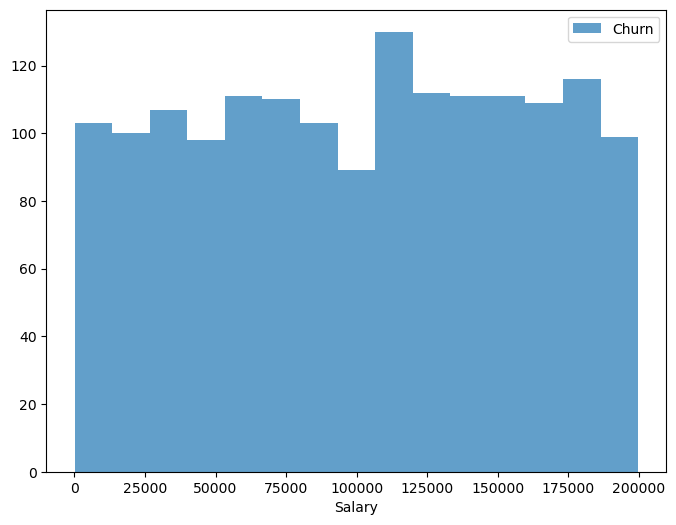

In [43]:
plt.figure(figsize=(8,6))
plt.xlabel('Salary')
plt.hist(churn["Salary"],bins=15, alpha=0.7, label='Churn')
plt.legend(loc='upper right')
plt.show()

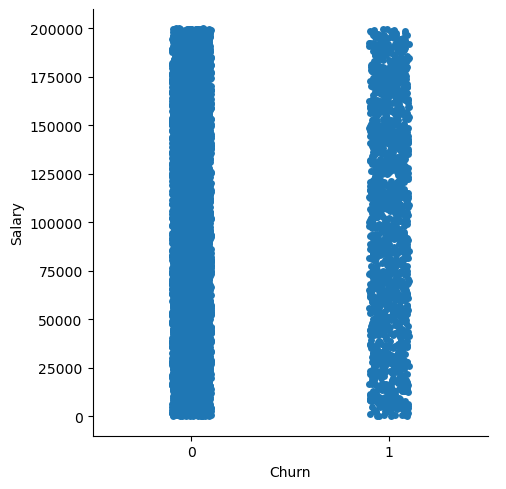

In [44]:
sns.catplot(x="Churn", y="Salary", data = df)

## 1.4 - Correlation matrix

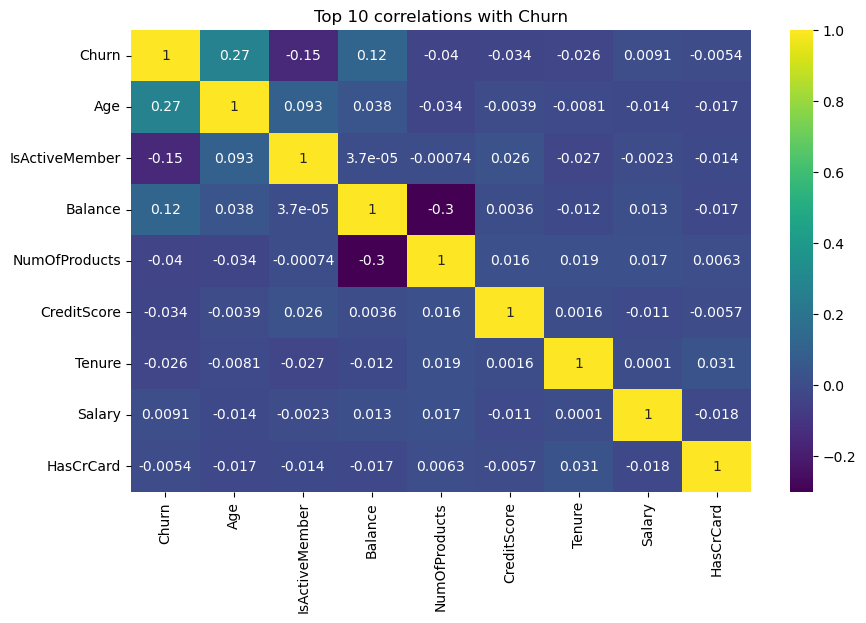

In [45]:
k = 10 # Number of variables for heatmap
target_col = "Churn"
corr = df.corr(numeric_only=True) 
cols = corr[target_col].abs().nlargest(k).index
cm = corr.loc[cols, cols]

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, cmap="viridis")
plt.title(f"Top {k} correlations with {target_col}")
plt.show()

# 2 - Preprocessing

## 2.1 - NaN & Duplicates

In [46]:
df.isnull().sum()

CreditScore       0
Geography         0
Gender            0
Age               0
Tenure            0
Balance           0
NumOfProducts     0
HasCrCard         0
IsActiveMember    0
Salary            0
Churn             0
dtype: int64

In [47]:
df[df.duplicated()]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Salary,Churn


In [48]:
df.duplicated().sum()

np.int64(0)

## 2.2 - Outliers

In [49]:
def outlier_thresholds(dataframe, variable, low_quantile=0.05, up_quantile=0.95):
    quantile_one = dataframe[variable].quantile(low_quantile)
    quantile_three = dataframe[variable].quantile(up_quantile)
    interquantile_range = quantile_three - quantile_one
    up_limit = quantile_three + 1.5 * interquantile_range
    low_limit = quantile_one - 1.5 * interquantile_range
    return low_limit, up_limit

In [50]:
def has_outliers(dataframe, numeric_columns, plot=False):
   # variable_names = []
    for col in numeric_columns:
        low_limit, up_limit = outlier_thresholds(dataframe, col)
        if dataframe[(dataframe[col] > up_limit) | (dataframe[col] < low_limit)].any(axis=None):
            number_of_outliers = dataframe[(dataframe[col] > up_limit) | (dataframe[col] < low_limit)].shape[0]
            print(col, " : ", number_of_outliers, "outliers")
            #variable_names.append(col)
            if plot:
                sns.boxplot(x=dataframe[col])
                plt.show()

In [51]:
for var in numeric_variables:
    print(var, "has " , has_outliers(df, [var]),  "Outliers")

CreditScore has  None Outliers
Age has  None Outliers
Balance has  None Outliers
Salary has  None Outliers


## 2.3 - Encoding

In [52]:
df["Gender_raw"] = df["Gender"]

label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# We could also apply get_dummies with Geography and Gender and thus remove the label_encoder for Gender.
# This would create a column Gender_Male, it is absolutely the same result. Here we use LabelEncoder and OneHotEncoder.

In [53]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Salary,Churn,Gender_raw,Geography_Germany,Geography_Spain
0,632,0,50,5,107959.39,1,1,1,6985,1,Female,True,False
1,649,0,42,7,0.00,2,0,1,22974,0,Female,False,False
2,595,1,29,6,150685.79,1,1,0,87771,0,Male,False,False
3,653,1,35,6,116662.96,2,1,1,23864,0,Male,False,True
4,559,0,40,7,144470.77,1,1,1,18918,0,Female,False,True


In [54]:
features = [c for c in df.columns if c not in ["Churn", "Gender_raw"]]

In [55]:
X = df[features]
y = df['Churn']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rd_state)

## 2.4 - Scalling

In [57]:
# We have to scale because otherwise, for example with this dataset, it will look like Salary is a much more important feature than Age.
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns, index=X_test.index)
# We simply use StandardScaler because there are no outliers so no need to write manually something robust to outliers via statistics.

In [58]:
X_train[:5], X_test[:5]

(      CreditScore    Gender       Age    Tenure   Balance  NumOfProducts  \
 1467     0.305652 -1.096858 -0.466551 -1.409909 -1.211825       0.797107   
 5768    -1.072304  0.911695 -1.427398  1.016300  1.292640      -0.909646   
 5714     0.480467  0.911695 -1.139144  1.016300  1.050698       0.797107   
 1578    -0.506725  0.911695  0.494296 -0.716706 -1.211825       0.797107   
 6958     0.562733 -1.096858  0.878635 -1.409909  1.301014       0.797107   
 
       HasCrCard  IsActiveMember    Salary  Geography_Germany  Geography_Spain  
 1467   0.649057       -1.038230  1.169379          -0.567005        -0.583846  
 5768   0.649057        0.963177  0.440248          -0.567005        -0.583846  
 5714   0.649057       -1.038230 -0.168733          -0.567005        -0.583846  
 1578   0.649057       -1.038230 -1.218721          -0.567005        -0.583846  
 6958   0.649057        0.963177 -0.013206           1.763652        -0.583846  ,
       CreditScore    Gender       Age    Tenure 

# 4 - Baseline Models 

## 4.1 - Logistic Regression

In [59]:
log_reg = LogisticRegression(random_state=rd_state)
log_reg.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [60]:
y_pred_log_reg = log_reg.predict(X_test)
y_pred_proba_log_reg = log_reg.predict_proba(X_test)[:, 1]

In [61]:
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
class_report_log_reg = classification_report(y_test, y_pred_log_reg)
auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)

In [62]:
print(conf_matrix_log_reg)
print(class_report_log_reg)
print(f"AUC-ROC: {auc_log_reg:.4f}")
print(f"Acc: {acc_log_reg}")

[[1236   34]
 [ 261   69]]
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1270
           1       0.67      0.21      0.32       330

    accuracy                           0.82      1600
   macro avg       0.75      0.59      0.61      1600
weighted avg       0.79      0.82      0.77      1600

AUC-ROC: 0.7556
Acc: 0.815625


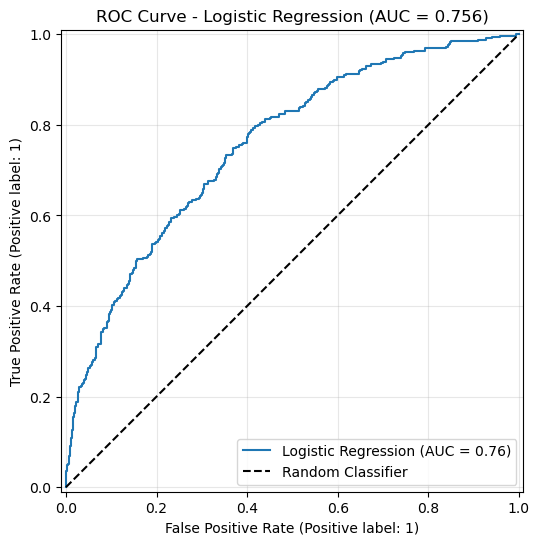

In [63]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_proba_log_reg, ax=ax, name='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title(f'ROC Curve - Logistic Regression (AUC = {auc_log_reg:.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4.2 - Random Forest 

In [64]:
rf = RandomForestClassifier(n_estimators=100, random_state=rd_state)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [65]:
y_pred_rf = rf.predict(X_test)
y_pred_rf_proba = rf.predict_proba(X_test)[:, 1]

In [66]:
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_rf_proba)
acc_rf = accuracy_score(y_test, y_pred_rf)

In [67]:
print(conf_matrix_rf)
print(class_report_rf)
print(f"AUC-ROC: {auc_rf:.4f}")
print(f"Acc: {acc_rf}")

[[1234   36]
 [ 185  145]]
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1270
           1       0.80      0.44      0.57       330

    accuracy                           0.86      1600
   macro avg       0.84      0.71      0.74      1600
weighted avg       0.86      0.86      0.85      1600

AUC-ROC: 0.8590
Acc: 0.861875


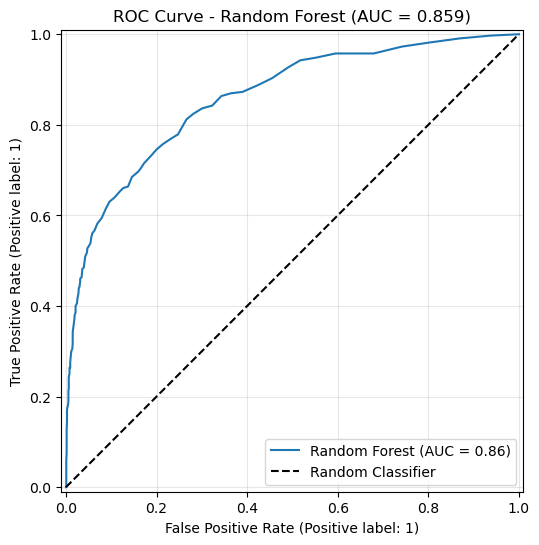

In [68]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_rf_proba, ax=ax, name='Random Forest')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title(f'ROC Curve - Random Forest (AUC = {auc_rf:.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4.3 - Support Vector Machine

In [69]:
svm = SVC(gamma='auto',random_state=rd_state,probability=True)
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [70]:
y_pred_svm = svm.predict(X_test)
y_pred_proba_svm = svm.predict_proba(X_test)[:, 1]

In [71]:
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
class_report_svm = classification_report(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_pred_proba_svm)
acc_svm = accuracy_score(y_test, y_pred_svm)

In [72]:
print(conf_matrix_svm)
print(class_report_svm)
print(f"AUC-ROC: {auc_svm:.4f}")
print(f"Acc: {acc_svm}")

[[1245   25]
 [ 213  117]]
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      1270
           1       0.82      0.35      0.50       330

    accuracy                           0.85      1600
   macro avg       0.84      0.67      0.70      1600
weighted avg       0.85      0.85      0.83      1600

AUC-ROC: 0.8405
Acc: 0.85125


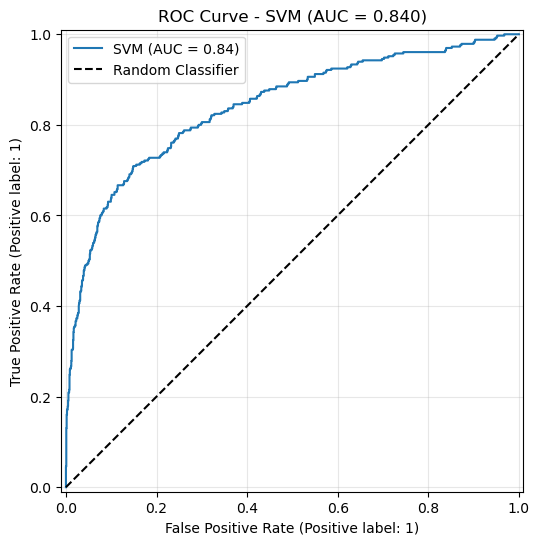

In [73]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_proba_svm, ax=ax, name='SVM')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title(f'ROC Curve - SVM (AUC = {auc_svm:.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4.4 - LightGBM

In [74]:
lightgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=rd_state)
lightgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1279, number of negative: 5121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199844 -> initscore=-1.387271
[LightGBM] [Info] Start training from score -1.387271


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [75]:
y_pred_lgb = lightgbm.predict(X_test)
y_pred_proba_lgb = lightgbm.predict_proba(X_test)[:, 1]

In [76]:
conf_matrix_lgb = confusion_matrix(y_test, y_pred_lgb)
class_report_lgb = classification_report(y_test, y_pred_lgb)
auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
acc_lgb = accuracy_score(y_test, y_pred_lgb)

In [77]:
print(conf_matrix_lgb)
print(class_report_lgb)
print(f"AUC-ROC: {auc_lgb:.4f}")
print(f"Acc: {acc_lgb}")

[[1217   53]
 [ 176  154]]
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1270
           1       0.74      0.47      0.57       330

    accuracy                           0.86      1600
   macro avg       0.81      0.71      0.74      1600
weighted avg       0.85      0.86      0.84      1600

AUC-ROC: 0.8607
Acc: 0.856875


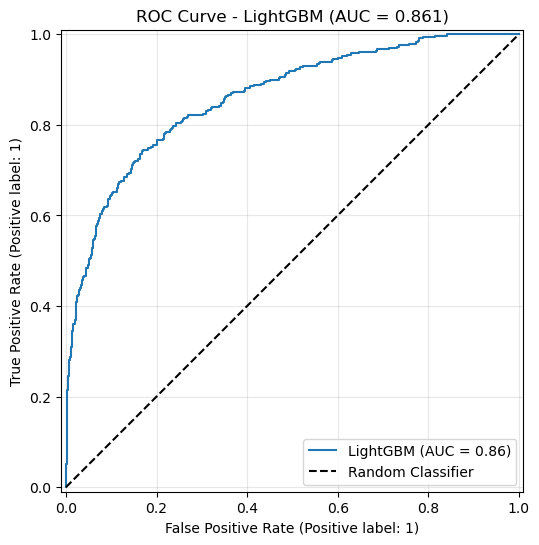

In [78]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_proba_lgb, ax=ax, name='LightGBM')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title(f'ROC Curve - LightGBM (AUC = {auc_lgb:.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4.5 - XGBoost

In [79]:
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=rd_state)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [80]:
y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

In [81]:
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
class_report_xgb = classification_report(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

In [82]:
print(conf_matrix_xgb)
print(class_report_xgb)
print(f"AUC-ROC: {auc_xgb:.4f}")
print(f"Acc: {acc_xgb}")

[[1219   51]
 [ 178  152]]
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1270
           1       0.75      0.46      0.57       330

    accuracy                           0.86      1600
   macro avg       0.81      0.71      0.74      1600
weighted avg       0.85      0.86      0.84      1600

AUC-ROC: 0.8641
Acc: 0.856875


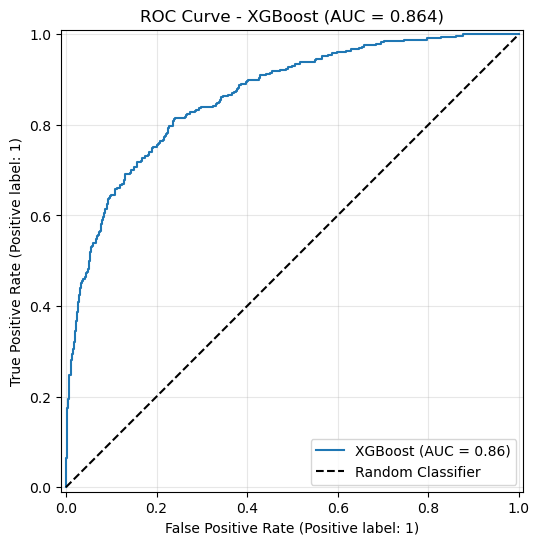

In [83]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_proba_xgb, ax=ax, name='XGBoost')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title(f'ROC Curve - XGBoost (AUC = {auc_xgb:.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4.6 - Baseline Feature Importance comparison

              Feature  RF_Importance  LGBM_Importance   LR_Coef
2                 Age       0.232946         0.159333  0.323476
8              Salary       0.146030         0.204889  0.020240
0         CreditScore       0.144110         0.202556  0.033751
4             Balance       0.143072         0.182333  0.082461
5       NumOfProducts       0.131699         0.052667  0.007187
3              Tenure       0.082942         0.085333  0.032223
7      IsActiveMember       0.041981         0.026444  0.233929
9   Geography_Germany       0.023794         0.028333  0.128455
6           HasCrCard       0.019161         0.013444  0.011334
1              Gender       0.018810         0.027889  0.116674
10    Geography_Spain       0.015455         0.016778  0.010271


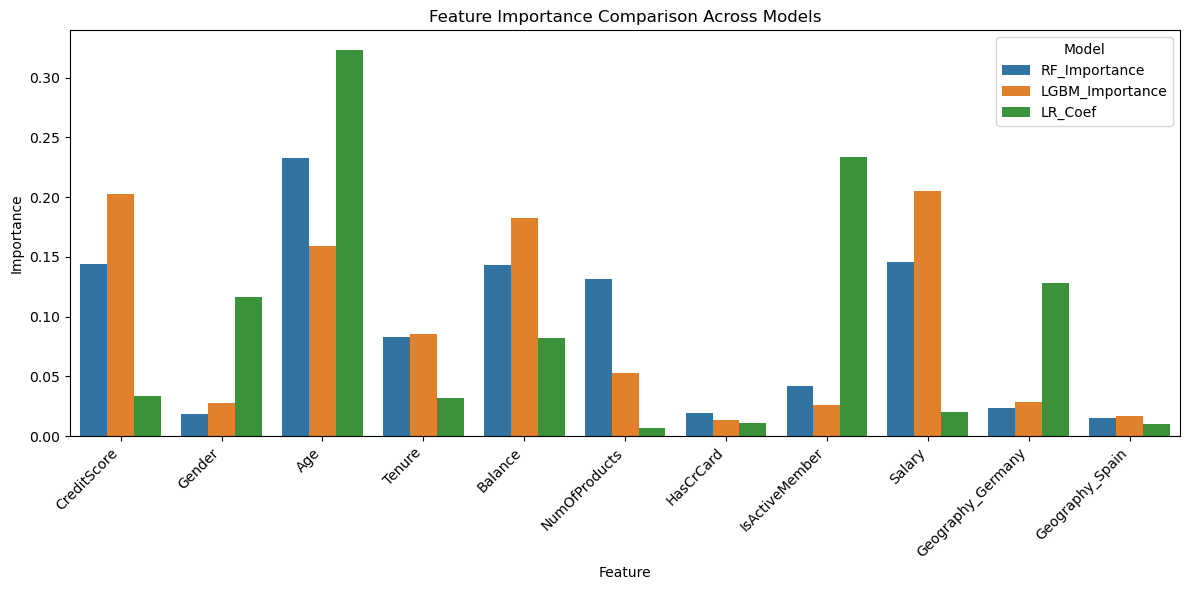

In [84]:
# Feature importance for Random Forest
fi_rf = pd.DataFrame({
    'Feature': features,
    'RF_Importance': rf.feature_importances_
})

# Feature importance for LightGBM
fi_lgb = pd.DataFrame({
    'Feature': features,
    'LGBM_Importance': lightgbm.feature_importances_
})

# Coefficients for Logistic Regression (absolute value)
fi_lr = pd.DataFrame({
    'Feature': features,
    'LR_Coef': np.abs(log_reg.coef_[0])
})

# Merge & normalize
fi_comparison = fi_rf.merge(fi_lgb, on='Feature').merge(fi_lr, on='Feature')

# Normalize to compare (0-1)
for col in ['RF_Importance', 'LGBM_Importance', 'LR_Coef']:
    fi_comparison[col] = fi_comparison[col] / fi_comparison[col].sum()

print(fi_comparison.sort_values('RF_Importance', ascending=False))


fi_comparison_melted = fi_comparison.melt(id_vars='Feature', var_name='Model', value_name='Importance')
plt.figure(figsize=(12, 6))
sns.barplot(data=fi_comparison_melted, x='Feature', y='Importance', hue='Model')
plt.xticks(rotation=45, ha='right')
plt.title('Feature Importance Comparison Across Models')
plt.tight_layout()
plt.show()

# 5 - Stratified Models and selection

In [85]:
X_full = df[features]
y_full = df['Churn']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=rd_state)

models_baseline = {
    'Logistic Regression': LogisticRegression(random_state=rd_state),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=rd_state),
    'SVM': SVC(gamma='auto', random_state=rd_state, probability=True),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=rd_state, verbose=-1),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=rd_state, eval_metric='logloss')
}

scoring = {"acc": "accuracy", "auc": "roc_auc"}

cv_results_baseline = {}

for name, model in models_baseline.items():
    print(f"\n{'='*70}")
    print(f"Validating: {name}")
    print(f"{'='*70}")
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])

    res = cross_validate(pipeline, X_full, y_full, cv=skf, scoring=scoring, n_jobs=-1)

    acc_mean, acc_std = res["test_acc"].mean(), res["test_acc"].std()
    auc_mean, auc_std = res["test_auc"].mean(), res["test_auc"].std()
    
    cv_results_baseline[name] = {
        "accuracy_mean": acc_mean, "accuracy_std": acc_std,
        "auc_mean": auc_mean, "auc_std": auc_std
    }
    
    print(f"Mean Accuracy: {acc_mean:.4f} (+/- {acc_std:.4f})")
    print(f"Mean AUC-ROC: {auc_mean:.4f} (+/- {auc_std:.4f})")


Validating: Logistic Regression
Mean Accuracy: 0.8114 (+/- 0.0061)
Mean AUC-ROC: 0.7550 (+/- 0.0147)

Validating: Random Forest
Mean Accuracy: 0.8620 (+/- 0.0056)
Mean AUC-ROC: 0.8487 (+/- 0.0106)

Validating: SVM
Mean Accuracy: 0.8575 (+/- 0.0070)
Mean AUC-ROC: 0.8207 (+/- 0.0131)

Validating: LightGBM
Mean Accuracy: 0.8601 (+/- 0.0082)
Mean AUC-ROC: 0.8555 (+/- 0.0081)

Validating: XGBoost
Mean Accuracy: 0.8619 (+/- 0.0059)
Mean AUC-ROC: 0.8568 (+/- 0.0082)


The stratified cross-validation confirms that Random Forest, LightGBM and XGBoost are the best models for this dataset in term of stability and performances. We choose them for now.

# 6 - Feature engineering

In [86]:
df_original = pd.read_csv("celldata.csv")
df_engineered = df_original.copy()

In [87]:
df_engineered["Gender_raw"] = df_engineered["Gender"]

In [88]:
df_engineered['AgeGroup'] = pd.cut(df_engineered['Age'], 
                                    bins=[0, 30, 40, 50, 100], 
                                    labels=['Young', 'MiddleAge', 'Senior', 'Elderly'])
df_engineered['AgeGroup'] = df_engineered['AgeGroup'].cat.codes

df_engineered['IsSenior'] = (df_engineered['Age'] > 50).astype(int)
df_engineered['Age_Squared'] = df_engineered['Age'] ** 2

In [89]:
df_engineered['BalanceGroup'] = pd.cut(df_engineered['Balance'], 
                                        bins=[-1, 0, 50000, 100000, 300000], 
                                        labels=['Zero', 'Low', 'Medium', 'High'])
df_engineered['BalanceGroup'] = df_engineered['BalanceGroup'].cat.codes

df_engineered['HasZeroBalance'] = (df_engineered['Balance'] == 0).astype(int)
df_engineered['BalancePerProduct'] = df_engineered['Balance'] / df_engineered['NumOfProducts']
df_engineered['BalanceSalaryRatio'] = df_engineered['Balance'] / (df_engineered['Salary'] + 1)


In [90]:
df_engineered['TenureGroup'] = pd.cut(df_engineered['Tenure'], 
                                       bins=[-1, 2, 5, 10], 
                                       labels=['Short', 'Medium', 'Long'])
df_engineered['TenureGroup'] = df_engineered['TenureGroup'].cat.codes

df_engineered['IsNewCustomer'] = (df_engineered['Tenure'] <= 2).astype(int)

In [91]:
salary_threshold = df_engineered['Salary'].quantile(0.75)
df_engineered['IsHighSalary'] = (df_engineered['Salary'] > salary_threshold).astype(int)

salary_low_threshold = df_engineered['Salary'].quantile(0.25)
df_engineered['IsLowSalary'] = (df_engineered['Salary'] < salary_low_threshold).astype(int)

In [92]:
df_engineered['Age_Balance_Interaction'] = df_engineered['Age'] * df_engineered['Balance'] / 100000
df_engineered['Age_NumProducts'] = df_engineered['Age'] * df_engineered['NumOfProducts']
df_engineered['Balance_NumProducts'] = df_engineered['Balance'] * df_engineered['NumOfProducts'] / 100000

In [93]:
df_engineered['EngagementScore'] = df_engineered['IsActiveMember'] + df_engineered['HasCrCard']
df_engineered['IsFullyEngaged'] = ((df_engineered['IsActiveMember'] == 1) & (df_engineered['HasCrCard'] == 1)).astype(int)
df_engineered['IsDisengaged'] = ((df_engineered['IsActiveMember'] == 0) & (df_engineered['HasCrCard'] == 0)).astype(int)

In [94]:
df_engineered['HasMultipleProducts'] = (df_engineered['NumOfProducts'] > 2).astype(int)
df_engineered['HasSingleProduct'] = (df_engineered['NumOfProducts'] == 1).astype(int)

In [95]:
label_encoder = LabelEncoder()
df_engineered['Gender'] = label_encoder.fit_transform(df_engineered['Gender'])
df_engineered = pd.get_dummies(df_engineered, columns=['Geography'], drop_first=True)

In [96]:
# New features

new_features = ['AgeGroup', 'IsSenior', 'Age_Squared','BalanceGroup', 'HasZeroBalance', 'BalancePerProduct', 'BalanceSalaryRatio','TenureGroup', 
                'IsNewCustomer','IsHighSalary', 'IsLowSalary','Age_Balance_Interaction', 'Age_NumProducts', 'Balance_NumProducts',
                'EngagementScore', 'IsFullyEngaged', 'IsDisengaged','HasMultipleProducts', 'HasSingleProduct']

features_engineered = [c for c in df_engineered.columns if c not in ["Churn", "Gender_raw"]]

In [97]:
print(df_engineered[new_features].head(10))

   AgeGroup  IsSenior  Age_Squared  BalanceGroup  HasZeroBalance  \
0         2         0         2500             3               0   
1         2         0         1764             0               1   
2         0         0          841             3               0   
3         1         0         1225             3               0   
4         1         0         1600             3               0   
5         0         0          576             0               1   
6         2         0         2025             3               0   
7         0         0          729             3               0   
8         1         0         1444             3               0   
9         0         0          784             0               1   

   BalancePerProduct  BalanceSalaryRatio  TenureGroup  IsNewCustomer  \
0          107959.39           15.453677            1              0   
1               0.00            0.000000            2              0   
2          150685.79            1.7

In [98]:
X_eng = df_engineered[features_engineered]
y_eng = df_engineered["Churn"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=rd_state)

models = {
    "Random Forest (FE)": RandomForestClassifier(n_estimators=100, random_state=rd_state),
    "LightGBM (FE)": LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=rd_state, verbose=-1),
    "XGBoost (FE)": XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=rd_state, eval_metric="logloss"),
}

scoring = {"acc": "accuracy", "auc": "roc_auc"}

cv_results = {}

for name, model in models.items():
    print(f"\n{'='*70}")
    print(f"Validating: {name}")
    print(f"{'='*70}")

    pipeline = Pipeline([
        ("scaler", StandardScaler()),   # optionnel pour ces modèles, mais ok si vous gardez un pipeline uniforme
        ("classifier", model),
    ])

    res = cross_validate(
        pipeline, X_eng, y_eng,
        cv=skf, scoring=scoring, n_jobs=-1
    )

    acc_mean, acc_std = res["test_acc"].mean(), res["test_acc"].std()
    auc_mean, auc_std = res["test_auc"].mean(), res["test_auc"].std()

    cv_results[name] = {
        "accuracy_mean": acc_mean, "accuracy_std": acc_std,
        "auc_mean": auc_mean, "auc_std": auc_std
    }

    print(f"Mean Accuracy: {acc_mean:.4f} (+/- {acc_std:.4f})")
    print(f"Mean AUC-ROC:  {auc_mean:.4f} (+/- {auc_std:.4f})")


Validating: Random Forest (FE)
Mean Accuracy: 0.8626 (+/- 0.0061)
Mean AUC-ROC:  0.8438 (+/- 0.0133)

Validating: LightGBM (FE)
Mean Accuracy: 0.8605 (+/- 0.0059)
Mean AUC-ROC:  0.8519 (+/- 0.0083)

Validating: XGBoost (FE)
Mean Accuracy: 0.8589 (+/- 0.0077)
Mean AUC-ROC:  0.8531 (+/- 0.0083)


                    Feature  RF_Importance  LGBM_Importance  XGB_Importance
2                       Age       0.081679         0.100222        0.108969
21          Age_NumProducts       0.077077         0.078556        0.050963
0               CreditScore       0.075247         0.166444        0.020924
11              Age_Squared       0.073032         0.001667        0.000000
8                    Salary       0.070545         0.142778        0.021727
20  Age_Balance_Interaction       0.057054         0.065889        0.032289
22      Balance_NumProducts       0.055919         0.054889        0.028351
14        BalancePerProduct       0.051819         0.041556        0.026940
15       BalanceSalaryRatio       0.049039         0.080000        0.031549
4                   Balance       0.048913         0.063000        0.036037
5             NumOfProducts       0.045314         0.027000        0.260295
3                    Tenure       0.044232         0.065222        0.019846
26      HasM

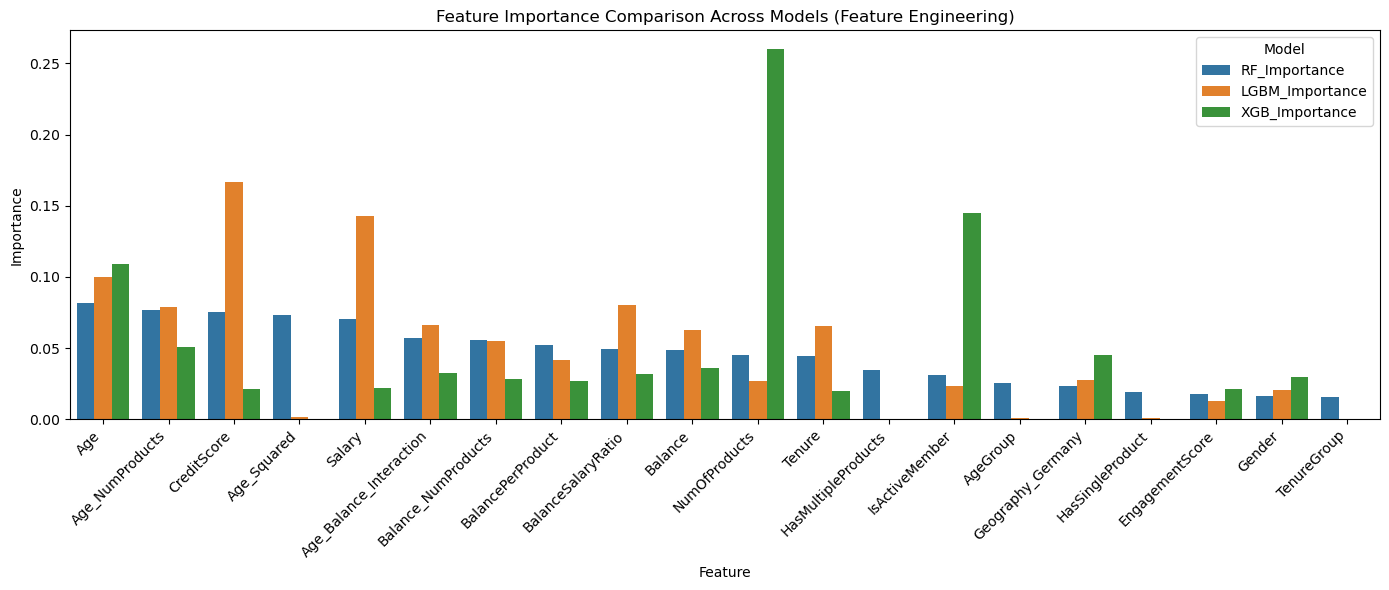

In [100]:
features_engineered = [c for c in df_engineered.columns if c not in ["Churn", "Gender_raw"]]

X_eng_full = df_engineered[features_engineered]
y_eng_full = df_engineered["Churn"]


scaler = StandardScaler()
X_eng_full_scaled = pd.DataFrame(
    scaler.fit_transform(X_eng_full),
    columns=features_engineered,
    index=df_engineered.index
)


rf_fe = RandomForestClassifier(n_estimators=100, random_state=rd_state)
lightgbm_fe = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=rd_state, verbose=-1)
xgb_fe = XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=rd_state, eval_metric="logloss")

rf_fe.fit(X_eng_full_scaled, y_eng_full)
lightgbm_fe.fit(X_eng_full_scaled, y_eng_full)
xgb_fe.fit(X_eng_full_scaled, y_eng_full)


fi_rf = pd.DataFrame({
    "Feature": features_engineered,
    "RF_Importance": rf_fe.feature_importances_
})

fi_lgb = pd.DataFrame({
    "Feature": features_engineered,
    "LGBM_Importance": lightgbm_fe.feature_importances_
})

fi_xgb = pd.DataFrame({
    "Feature": features_engineered,
    "XGB_Importance": xgb_fe.feature_importances_
})


fi_comparison_fe = fi_rf.merge(fi_lgb, on="Feature").merge(fi_xgb, on="Feature")

for col in ["RF_Importance", "LGBM_Importance", "XGB_Importance"]:
    fi_comparison_fe[col] = fi_comparison_fe[col] / fi_comparison_fe[col].sum()


top_n = 20
fi_comparison_fe = fi_comparison_fe.sort_values("RF_Importance", ascending=False).head(top_n)

print(fi_comparison_fe)


fi_melted = fi_comparison_fe.melt(id_vars="Feature", var_name="Model", value_name="Importance")

plt.figure(figsize=(14, 6))
sns.barplot(data=fi_melted, x="Feature", y="Importance", hue="Model")
plt.xticks(rotation=45, ha="right")
plt.title("Feature Importance Comparison Across Models (Feature Engineering)")
plt.tight_layout()
plt.show()

# 7 - Hyperparameter tuning

In [106]:
class SalaryQuantileFlags(BaseEstimator, TransformerMixin):
    def __init__(self, salary_col="Salary", q_low=0.25, q_high=0.75):
        self.salary_col = salary_col
        self.q_low = q_low
        self.q_high = q_high

    def fit(self, X, y=None):
        X_ = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        s = X_[self.salary_col]
        self.low_ = float(s.quantile(self.q_low))
        self.high_ = float(s.quantile(self.q_high))
        return self

    def transform(self, X):
        X_ = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X).copy()
        X_["IsHighSalary"] = (X_[self.salary_col] > self.high_).astype(int)
        X_["IsLowSalary"] = (X_[self.salary_col] < self.low_).astype(int)
        return X_

In [110]:
features_engineered = [c for c in df_engineered.columns if c not in ["Churn", "Gender_raw"]]

X_eng = df_engineered[features_engineered]
y_eng = df_engineered["Churn"]

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rd_state)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=rd_state)


rf = RandomForestClassifier(random_state=rd_state)
lgbm = LGBMClassifier(random_state=rd_state, verbose=-1)
xgb = XGBClassifier(random_state=rd_state, eval_metric="logloss")

def make_scaler():
    s = StandardScaler()
    if hasattr(s, "set_output"):
        s = s.set_output(transform="pandas")
    return s


pipe_rf = Pipeline([
    ("salary_flags", SalaryQuantileFlags(salary_col="Salary")),
    ("scaler", make_scaler()),
    ("classifier", RandomForestClassifier(random_state=rd_state)),
])

pipe_lgbm = Pipeline([
    ("salary_flags", SalaryQuantileFlags(salary_col="Salary")),
    ("scaler", make_scaler()),
    ("classifier", LGBMClassifier(random_state=rd_state, verbose=-1)),
])

pipe_xgb = Pipeline([
    ("salary_flags", SalaryQuantileFlags(salary_col="Salary")),
    ("scaler", make_scaler()),
    ("classifier", XGBClassifier(random_state=rd_state, eval_metric="logloss")),
])


param_rf = {
    "classifier__n_estimators": [100, 200, 400],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2", None],
}

param_lgbm = {
    "classifier__n_estimators": [200, 300, 500, 800],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__num_leaves": [15, 31, 63, 127],
    "classifier__max_depth": [-1, 5, 10, 20],
    "classifier__subsample": [0.7, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.9, 1.0],
}

param_xgb = {
    "classifier__n_estimators": [200, 300, 500, 800],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_depth": [3, 5, 7, 10],
    "classifier__min_child_weight": [1, 5, 10],
    "classifier__subsample": [0.7, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.9, 1.0],
    "classifier__reg_lambda": [1.0, 5.0, 10.0],
}

In [111]:
search_specs = [
    ("Random Forest (FE)", pipe_rf, param_rf),
    ("LightGBM (FE)", pipe_lgbm, param_lgbm),
    ("XGBoost (FE)", pipe_xgb, param_xgb),
]

nested_summary = []
final_models = {}

for name, pipe, params in search_specs:
    print("\n" + "="*90)
    print(f"NESTED CV (outer=5 folds, inner=3 folds) — {name}")
    print("="*90)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=params,
        n_iter=25,
        scoring="roc_auc",
        cv=inner_cv,
        n_jobs=-1,
        random_state=rd_state,
        verbose=0,
        refit=True
    )

    
    res = cross_validate(
        search,
        X_eng, y_eng,
        cv=outer_cv,
        scoring=scoring,
        n_jobs=1,
        return_estimator=True
    )

    acc_mean, acc_std = res["test_acc"].mean(), res["test_acc"].std()
    auc_mean, auc_std = res["test_auc"].mean(), res["test_auc"].std()

    print(f"Nested Mean Accuracy: {acc_mean:.4f} (+/- {acc_std:.4f})")
    print(f"Nested Mean AUC-ROC:  {auc_mean:.4f} (+/- {auc_std:.4f})")

    # Best params par fold outer 
    best_params_per_fold = [est.best_params_ for est in res["estimator"]]
    print("Best params (outer folds) — first 2 folds:")
    for i, bp in enumerate(best_params_per_fold[:2], start=1):
        print(f"  Fold {i}: {bp}")

    nested_summary.append({
        "Model": name,
        "Nested_Acc_mean": acc_mean, "Nested_Acc_std": acc_std,
        "Nested_AUC_mean": auc_mean, "Nested_AUC_std": auc_std,
    })

    
    print("\nFitting FINAL tuned model on full FE data...")
    search.fit(X_eng, y_eng)
    final_models[name] = search.best_estimator_
    print("Final best AUC (inner CV):", search.best_score_)
    print("Final best params:", search.best_params_)

nested_df = pd.DataFrame(nested_summary).sort_values("Nested_AUC_mean", ascending=False)
print("\n" + "="*90)
print("NESTED CV SUMMARY (robuste, trié par AUC)")
print("="*90)
print(nested_df)


print("\n" + "="*90)
print("OPTIONAL: Stratified CV on FINAL tuned estimators (optimiste, pour check)")
print("="*90)

final_cv_rows = []
for name, est in final_models.items():
    res_final = cross_validate(est, X_eng, y_eng, cv=outer_cv, scoring=scoring, n_jobs=-1)
    final_cv_rows.append({
        "Model": name,
        "FinalCV_Acc_mean": res_final["test_acc"].mean(),
        "FinalCV_Acc_std": res_final["test_acc"].std(),
        "FinalCV_AUC_mean": res_final["test_auc"].mean(),
        "FinalCV_AUC_std": res_final["test_auc"].std(),
    })

final_cv_df = pd.DataFrame(final_cv_rows).sort_values("FinalCV_AUC_mean", ascending=False)
print(final_cv_df)


NESTED CV (outer=5 folds, inner=3 folds) — Random Forest (FE)
Nested Mean Accuracy: 0.8643 (+/- 0.0027)
Nested Mean AUC-ROC:  0.8572 (+/- 0.0111)
Best params (outer folds) — first 2 folds:
  Fold 1: {'classifier__n_estimators': 400, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 10}
  Fold 2: {'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': 10}

Fitting FINAL tuned model on full FE data...
Final best AUC (inner CV): 0.8582946713851087
Final best params: {'classifier__n_estimators': 400, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 10}

NESTED CV (outer=5 folds, inner=3 folds) — LightGBM (FE)
Nested Mean Accuracy: 0.8618 (+/- 0.0083)
Nested Mean AUC-ROC:  0.8574 (+/- 0.0094)
Best params (outer folds) — first 2 folds:
  Fold 1: {'classifier__subsample': 0.9, 'classifier__num_leaves': 31, 'classifier__n_estima

# 8 - Fairness analysis

In [114]:
xgb_est = None
if "final_models" in globals() and "XGBoost (FE)" in final_models:
    xgb_est = final_models["XGBoost (FE)"]
elif "best_models" in globals() and "XGBoost (FE)" in best_models:
    xgb_est = best_models["XGBoost (FE)"]
else:
    raise ValueError("No XGBoost")


features_engineered = [c for c in df_engineered.columns if c not in ["Churn", "Gender_raw"]]
X = df_engineered[features_engineered]
y = df_engineered["Churn"].astype(int)

A = df_engineered["Gender_raw"].astype(str) 



cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rd_state)

proba_oof = cross_val_predict(
    xgb_est, X, y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


threshold = 0.5
yhat_oof = (proba_oof >= threshold).astype(int)

print("OOF computed. threshold =", threshold)
print("Groups:", sorted(A.unique()))

OOF computed. threshold = 0.5
Groups: ['Female', 'Male']


In [115]:
def _safe_div(a, b):
    return a / b if b > 0 else np.nan

def group_fairness_metrics(y, yhat, proba, A):
    dfm = pd.DataFrame({"y": y, "yhat": yhat, "p": proba, "A": A})

    rows = []
    for g, d in dfm.groupby("A"):
        n = len(d)

        # Base rate
        base_rate = d["y"].mean()  # P(Y=1|A)

        # Independence (Demographic parity)
        ppr = d["yhat"].mean()     # P(Ŷ=1|A)

        # Separation (Equalized odds) : TPR/FPR
        d1 = d[d["y"] == 1]
        d0 = d[d["y"] == 0]
        tpr = _safe_div((d1["yhat"] == 1).sum(), len(d1))  # P(Ŷ=1|Y=1,A)
        fpr = _safe_div((d0["yhat"] == 1).sum(), len(d0))  # P(Ŷ=1|Y=0,A)

        # Sufficiency (Predictive parity, version binaire) : PPV/NPV
        dh1 = d[d["yhat"] == 1]
        dh0 = d[d["yhat"] == 0]
        ppv = _safe_div((dh1["y"] == 1).sum(), len(dh1))   # P(Y=1|Ŷ=1,A)
        npv = _safe_div((dh0["y"] == 0).sum(), len(dh0))   # P(Y=0|Ŷ=0,A)

        rows.append({
            "Group": g,
            "n": n,
            "BaseRate_P(Y=1|A)": base_rate,
            "Independence_P(Ŷ=1|A)": ppr,
            "Separation_TPR": tpr,
            "Separation_FPR": fpr,
            "Sufficiency_PPV": ppv,
            "Sufficiency_NPV": npv,
        })

    out = pd.DataFrame(rows).set_index("Group").sort_index()

    # Gaps (max-min)
    gap = (out.max(numeric_only=True) - out.min(numeric_only=True)).to_frame().T
    gap.index = ["GAP(max-min)"]

    ppr_vals = out.loc[out.index != "GAP(max-min)", "Independence_P(Ŷ=1|A)"].dropna()
    di = (ppr_vals.min() / ppr_vals.max()) if len(ppr_vals) >= 2 and ppr_vals.max() > 0 else np.nan

    out2 = pd.concat([out, gap], axis=0)
    out2.loc["DisparateImpact(min/max PPR)", :] = np.nan
    out2.loc["DisparateImpact(min/max PPR)", "Independence_P(Ŷ=1|A)"] = di

    return out2

fair_table = group_fairness_metrics(y, yhat_oof, proba_oof, A)
print(fair_table)

                                   n  BaseRate_P(Y=1|A)  \
Female                        3627.0           0.247312   
Male                          4373.0           0.162817   
GAP(max-min)                   746.0           0.084495   
DisparateImpact(min/max PPR)     NaN                NaN   

                              Independence_P(Ŷ=1|A)  Separation_TPR  \
Female                                     0.147781        0.471572   
Male                                       0.092156        0.421348   
GAP(max-min)                               0.055624        0.050224   
DisparateImpact(min/max PPR)               0.623603             NaN   

                              Separation_FPR  Sufficiency_PPV  Sufficiency_NPV  
Female                              0.041392         0.789179         0.846652  
Male                                0.028134         0.744417         0.896222  
GAP(max-min)                        0.013258         0.044762         0.049570  
DisparateImpact(min/max 

             ECE
Group           
Female  0.012921
Male    0.018473


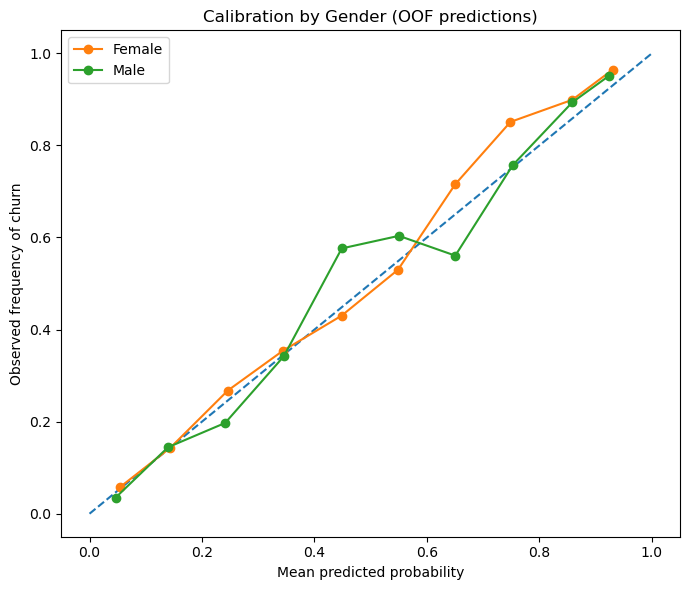

In [117]:
def ece_by_group(y, proba, A, n_bins=10):
    dfc = pd.DataFrame({"y": y, "p": proba, "A": A})
    bins = np.linspace(0, 1, n_bins + 1)

    rows = []
    for g, d in dfc.groupby("A"):
        d = d.copy()
        d["bin"] = pd.cut(d["p"], bins=bins, include_lowest=True)
        agg = d.groupby("bin", observed=False).agg(
            p_mean=("p", "mean"),
            y_mean=("y", "mean"),
            w=("y", "size")
        ).dropna()

        if agg["w"].sum() == 0:
            ece = np.nan
        else:
            agg["w"] = agg["w"] / agg["w"].sum()
            ece = (agg["w"] * (agg["p_mean"] - agg["y_mean"]).abs()).sum()

        rows.append({"Group": g, "ECE": ece})
    return pd.DataFrame(rows).set_index("Group").sort_index()

ece_df = ece_by_group(y, proba_oof, A, n_bins=10)
print(ece_df)


def plot_calibration_by_group(y, proba, A, n_bins=10):
    dfc = pd.DataFrame({"y": y, "p": proba, "A": A})
    bins = np.linspace(0, 1, n_bins + 1)

    plt.figure(figsize=(7, 6))
    plt.plot([0, 1], [0, 1], linestyle="--")

    for g, d in dfc.groupby("A"):
        d = d.copy()
        d["bin"] = pd.cut(d["p"], bins=bins, include_lowest=True)
        agg = d.groupby("bin", observed=False).agg(
            p_mean=("p", "mean"),
            y_mean=("y", "mean")
        ).dropna()
        plt.plot(agg["p_mean"], agg["y_mean"], marker="o", label=str(g))

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed frequency of churn")
    plt.title("Calibration by Gender (OOF predictions)")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_calibration_by_group(y, proba_oof, A, n_bins=10)

In [119]:
group_rows = fair_table.loc[~fair_table.index.isin(["GAP(max-min)", "DisparateImpact(min/max PPR)"])].copy()


gap_row = fair_table.loc["GAP(max-min)"].copy()
di_val = fair_table.loc["DisparateImpact(min/max PPR)", "Independence_P(Ŷ=1|A)"]


cols_order = [
    "n",
    "BaseRate_P(Y=1|A)",
    "Independence_P(Ŷ=1|A)",
    "Separation_TPR",
    "Separation_FPR",
    "Sufficiency_PPV",
    "Sufficiency_NPV",
]
summary_groups = group_rows[cols_order].copy()
summary_groups = summary_groups.round(4)

display(summary_groups)


gaps = pd.DataFrame({
    "Independence gap (PPR)": [gap_row["Independence_P(Ŷ=1|A)"]],
    "Separation gap (TPR)": [gap_row["Separation_TPR"]],
    "Separation gap (FPR)": [gap_row["Separation_FPR"]],
    "Sufficiency gap (PPV)": [gap_row["Sufficiency_PPV"]],
    "Sufficiency gap (NPV)": [gap_row["Sufficiency_NPV"]],
    "Disparate impact (min/max PPR)": [di_val],
}).round(4)

display(gaps)


ece_clean = ece_df.copy().round(4)
ece_clean.columns = ["ECE (10 bins)"]
display(ece_clean)


ppr_gap = float(gap_row["Independence_P(Ŷ=1|A)"])
tpr_gap = float(gap_row["Separation_TPR"])
fpr_gap = float(gap_row["Separation_FPR"])
ppv_gap = float(gap_row["Sufficiency_PPV"])
ece_max = float(ece_clean["ECE (10 bins)"].max())

print("\nFAIRNESS QUICK READ:")
print(f"- Independence (PPR gap): {ppr_gap:.4f}  | DI(min/max): {di_val:.4f}")
print(f"- Separation (TPR gap):   {tpr_gap:.4f}  | (FPR gap): {fpr_gap:.4f}")
print(f"- Sufficiency (PPV gap):  {ppv_gap:.4f}")
print(f"- Calibration (max ECE):  {ece_max:.4f}")

,n,BaseRate_P(Y=1|A),Independence_P(Ŷ=1|A),Separation_TPR,Separation_FPR,Sufficiency_PPV,Sufficiency_NPV
Female,3627.0,0.2473,0.1478,0.4716,0.0414,0.7892,0.8467
Male,4373.0,0.1628,0.0922,0.4213,0.0281,0.7444,0.8962


,Independence gap (PPR),Separation gap (TPR),Separation gap (FPR),Sufficiency gap (PPV),Sufficiency gap (NPV),Disparate impact (min/max PPR)
0,0.0556,0.0502,0.0133,0.0448,0.0496,0.6236


,ECE (10 bins)
Group,
Female,0.0129
Male,0.0185



FAIRNESS QUICK READ:
- Independence (PPR gap): 0.0556  | DI(min/max): 0.6236
- Separation (TPR gap):   0.0502  | (FPR gap): 0.0133
- Sufficiency (PPV gap):  0.0448
- Calibration (max ECE):  0.0185
